# Examining how the pipeline performs with each detected combination.

- Let's examine one of each manually and make the pipeline work for them.
- 3sml: hd18256
- 2sm: hd10072
- 2ml: hd16673
- 1m: hd11131
- 0: hd10700

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.df_ops import prepare_df, split_df, clean_df
from helpers.priors import find_classify_signals, get_priors

SEED = 1701
error_percent = 5

def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)


## 3sml: HD18256


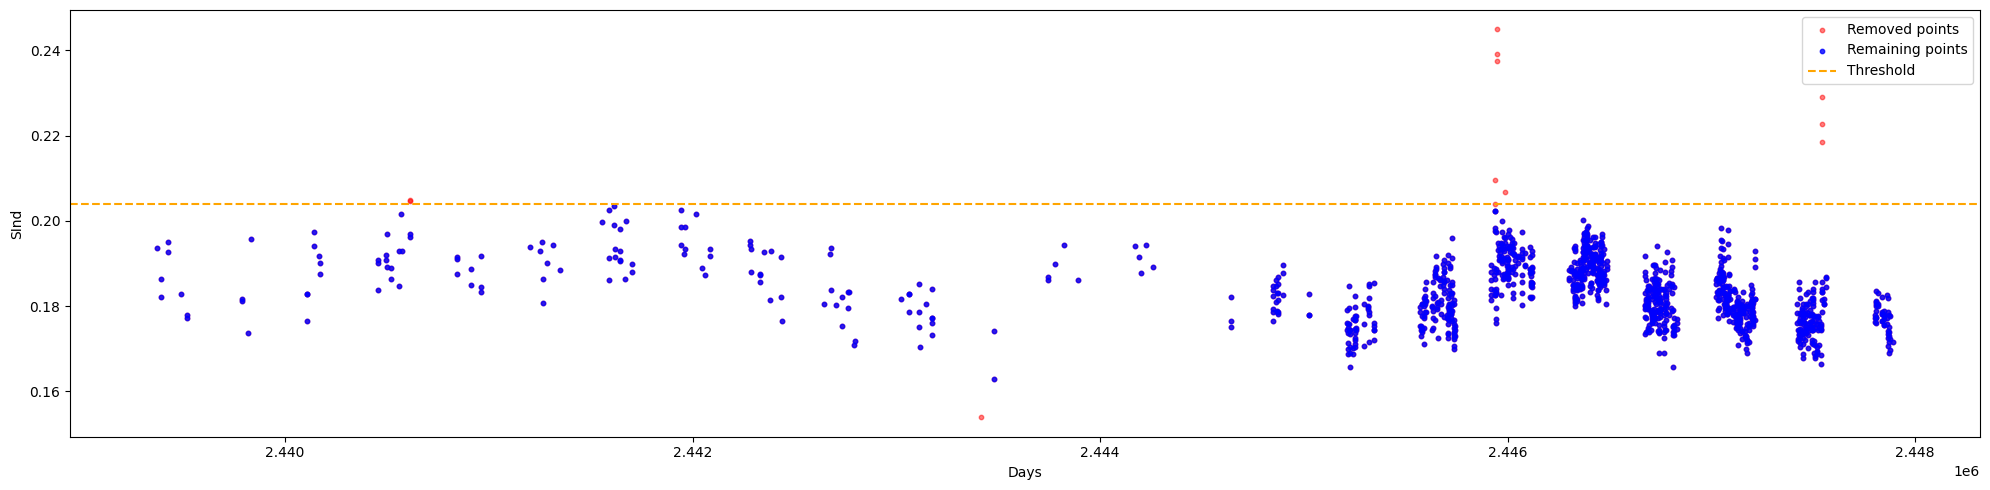

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2120.40 days was accepted.
Peak at period 544.32 days was identified to be an alias of 2120.40 days at mult 0.25 by tolerance 0.03.
Peak at period 1110.80 days was identified to be an alias of 2120.40 days at mult 0.50 by tolerance 0.05.
In iteration 1, period at 581.91 days was accepted.
In iteration 2, period at 13977.15 days was accepted.
Peak at period 174.94 days was identified to be a window of 182.62 days by tolerance 0.04.
In iteration 3, period at 337.00 days was accepted.
Peak at period 84.42 days was identified to be an alias of 337.00 days at mult 0.25 by tolerance 0.00.
In iteration 4, period at 155.96 days was accepted.
Peak at period 1367.40 days was identified to be an alias of 337.00 days at mult 4.00 by tolerance 0.01.
Peak at period 84.42 days was identified to be an alias of 337.00 days at mult 0.25 by tolerance 0.00.
Peak at period 1125.04 days was identified to be an alias of 581.91 days at mult 2.00 by tolerance 0.03.
Iteration 5 did not

In [3]:
from helpers.priors import find_classify_signals

#--- set params

datapath = r"../../Data/hd18256_caii.txt"
add_prefix = True
relative = True
train_split = 0.8
valid_split = 0.19

#---

raw_df = pd.read_csv(datapath, sep=r'\s+', skip_blank_lines=True)

# Prep the df adds the column names etc
data_df = prepare_df(raw_df, add_prefix=add_prefix, relative=relative)

# Split the data
dirty_train_df, valid_df, test_df = split_df(data_df,
                                                train_split=train_split, valid_split=valid_split)

# Clean the dataset for outliers
train_df = clean_df(dirty_train_df, tol=4,
                        verbose=False, plot=True)

# Classify signal data and get priors
classified_signal_data = find_classify_signals(dirty_train_df,
                                        plot_fitpeaks=False, verbose_fitpeaks=False,
                                        plot_genpriors=False, verbose_genpriors=True)

- Found all three so the priors should be the same.

In [4]:
# Get the concomitant priors
star_type = "F"
priors = get_priors(classified_signal_data,
                                        star_type=star_type,
                                        verbose=True)

+------------+------------+-------------+--------+
| Cycle Type | Prior Days | Prior Years | Source |
+------------+------------+-------------+--------+
|   Short    |   155.96   |     0.43    | found  |
|    Mid     |  2120.40   |     5.81    | found  |
|    Long    |  13977.15  |    38.29    | found  |
+------------+------------+-------------+--------+


- Let's see how well it predicts.

In [8]:
require_mid = True
sigma_upper_mult = 5
rho_bound_mults = [0.9, 1.1]
q_bounds_in = [5, 100]
loop_verbose = True
loop_plot = False
loop_savefigs = False
star_name = "HD18256"
results_verbose = True
results_plot = True
ax = None

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 1
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0097 | 5.00 |  2167.86   |     5.94    |
+--------+------+------------+-------------+
Mean NLPD on validation set (1m): -3.4327
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0019 | 5.00 |   171.55   |     0.47    |
| 0.0080 | 5.00 |  2331.84   |     6.39    |
+--------+------+------------+-------------+
Mean NLPD on validation set (2sm): -3.4481
True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+-------+------------+-------------+
| sigma  |   Q   | rho (days) | rho (years) |
+--------+-------+------------+-------------+
| 0.0069 |  5.00 |  2032.81   |     5.57    |
| 0.0030 | 39.97 |  15374.86  | 

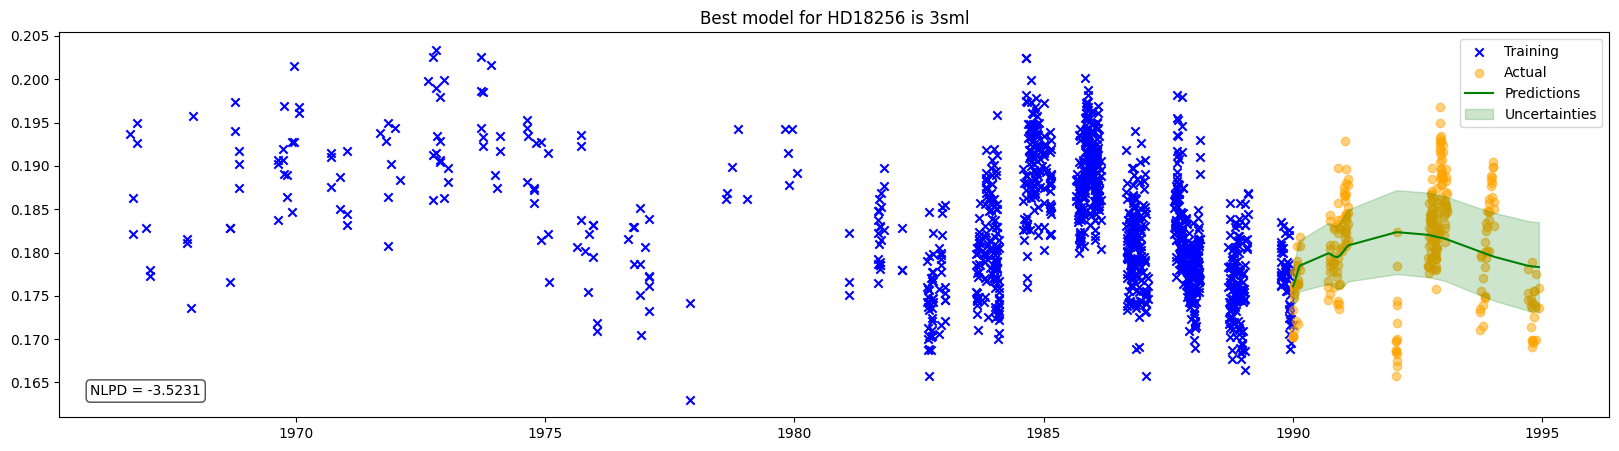

In [9]:
#-----Do the model training and comparison---------
train_yerr = train_df['sind'] * error_percent / 100

train_mean = train_df['sind'].mean()
train_std  = train_df['sind'].std()

# Define the prior combos to try
prior_combos = {
"1s":   (1, [priors['short']]),
"1m":   (1, [priors['mid']]),
"1l":   (1, [priors['long']]),

"2sm":  (2, [priors['short'], priors['mid']]),
"2ml":  (2, [priors['mid'],   priors['long']]),
"2ls":  (2, [priors['long'],  priors['short']]),

"3sml": (3, [priors['short'], priors['mid'], priors['long']]),
}

if require_mid:
        prior_combos = {k: v for k, v in prior_combos.items() if priors['mid'] in v[1]}

# Set up the loop
best_combo  = None
best_NLPD   = np.inf
best_gp     = None
best_params = None

# Run the loop
for combo_name, (k, prior_combo) in prior_combos.items():
        np.random.seed(SEED)

        sigma_0s = [train_std / k for _ in range(k)]
        rho_0s   = prior_combo
        q_0s     = [np.random.uniform(0.5, 1) for _ in range(k)]

        initial_guess = np.concatenate([
                np.log(sigma_0s),
                np.log(rho_0s),
                np.log(q_0s)
        ])

        sigma_upper  = train_std * sigma_upper_mult
        sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
        rho_bounds   = [(np.log(rho * rho_bound_mults[0]), np.log(rho * rho_bound_mults[1])) for rho in rho_0s]
        q_bounds     = [(np.log(q_bounds_in[0]), np.log(q_bounds_in[1])) for _ in range(k)]

        bounds = np.concatenate([sigma_bounds, rho_bounds, q_bounds])

        # Create the initial kernel for this iteration
        kernel = terms.SHOTerm(sigma=sigma_0s[0], rho=rho_0s[0], Q=q_0s[0])
        for k_idx in range(1, k):
                kernel += terms.SHOTerm(sigma=sigma_0s[k_idx], rho=rho_0s[k_idx], Q=q_0s[k_idx])

        # Define and compute the GP
        gp = celerite2.GaussianProcess(kernel, mean=train_mean)
        gp.compute(train_df['day'], yerr=train_yerr)

        # Train the GP
        gp_results = minimize(
                NLL, initial_guess,
                args=(gp, k, train_df['sind'].to_numpy()),
                method='L-BFGS-B',
                bounds=bounds
                )

        gp   = set_params(gp_results.x, k, gp)
        gp.recompute()
        best = np.exp(gp_results.x)

        if loop_verbose:
                table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
                best_sigmas = best[0:k]
                best_rhos   = best[k:2*k]
                best_qs     = best[2*k:]
                for k_idx in range(k):
                        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                        f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
                print(gp_results.success, gp_results.message)
                print(f"For k = {k}")
                print(table)

        # Predict on validation set
        mu, cov = gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
        std = np.sqrt(cov)

        # Model comparison via NLPD
        y_valid    = valid_df['sind'].to_numpy()
        valid_yerr = valid_df['sind'] * error_percent / 100
        total_var  = cov + valid_yerr**2
        nlpd_per_point = 0.5 * np.log(2 * np.pi * total_var) + (y_valid - mu)**2 / (2 * total_var)
        mean_nlpd = nlpd_per_point.mean()

        if mean_nlpd < best_NLPD:
                best_combo  = combo_name
                best_NLPD   = mean_nlpd
                best_gp     = gp
                best_params = best

        if loop_plot:
                loop_fig, loop_ax = plt.subplots(figsize=(20, 5))
                loop_ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
                loop_ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
                
                loop_ax.set_title(star_name + " " + combo_name)

                loop_ax.plot(valid_df['year'], mu, color='green', label='Predictions')
                loop_ax.fill_between(valid_df['year'], mu - std, mu + std,
                                        color='green', alpha=0.2, label='Uncertainties')
                
                loop_ax.legend()

                loop_ax.text(0.02, 0.05, f"NLPD = {mean_nlpd:.4f}",
                        transform=loop_ax.transAxes, fontsize=10, verticalalignment='bottom',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
                
                if loop_savefigs:
                        loop_fig.savefig(f"./figs/gpr_{star_name}_{int(round(train_split * 100)):02d}_{combo_name}.png", dpi=100, bbox_inches='tight')
                        plt.close(loop_fig)

                else:
                        plt.show()

        if loop_verbose:
                print(f"Mean NLPD on validation set ({combo_name}): {mean_nlpd:.4f}")

#-------Now we have the best model------

# Predict the best model once
mu, cov = best_gp.predict(train_df['sind'], t=valid_df['day'], return_var=True)
std = np.sqrt(cov)
results = pd.DataFrame({
        'forecast': mu,
        'lower':    mu - std,
        'upper':    mu + std,
}, index=valid_df.index)

if results_verbose: # Print best model params
        print(f"The best params were found for {best_combo} with NLPD of {best_NLPD}.")
        (k, prior_combo) = prior_combos[best_combo]
        table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
        best_sigmas = best_params[0:k]
        best_rhos   = best_params[k:2*k]
        best_qs     = best_params[2*k:]
        for k_idx in range(k):
                table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",
                                f"{best_rhos[k_idx]:.2f}", f"{best_rhos[k_idx]/365:.2f}"])
        print(table)

if results_plot: # Plot best model predictions
        if ax is None: # Enables passthrough
                fig, ax = plt.subplots(figsize=(20, 5))
        ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker='x')
        ax.scatter(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha=0.5)
        ax.set_title(f"Best model for {star_name} is {best_combo}")
        ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
        ax.fill_between(valid_df['year'], results['lower'], results['upper'],
                        color='green', alpha=0.2, label='Uncertainties')
        ax.legend()
        ax.text(0.02, 0.05, f"NLPD = {best_NLPD:.4f}",
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

- Ok this is pretty decent.
- Let's do the window analysis on this. 
- Because this used an unwrapped version of train_gpr, let's just use the GPR window function.